In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns 

In [2]:
data = {
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20],
    # "HitRate": [0.5604, 0.6430, 0.6453, 0.6447, 0.6271],
    "nDCG": [0.3208, 0.3743, 0.3730, 0.3737, 0.3646],
    "Precision": [0.0560, 0.0643, 0.0645, 0.0644, 0.0627],
    "Recall": [0.5604, 0.6430, 0.6453, 0.6447, 0.6271],
}

In [3]:
df = pd.DataFrame(data)
df = df.sort_values("nr", ascending=False)
df

,nr,nDCG,Precision,Recall
0,0.95,0.3208,0.0560,0.5604
1,0.80,0.3743,0.0643,0.6430
2,0.60,0.3730,0.0645,0.6453
3,0.40,0.3737,0.0644,0.6447
4,0.20,0.3646,0.0627,0.6271


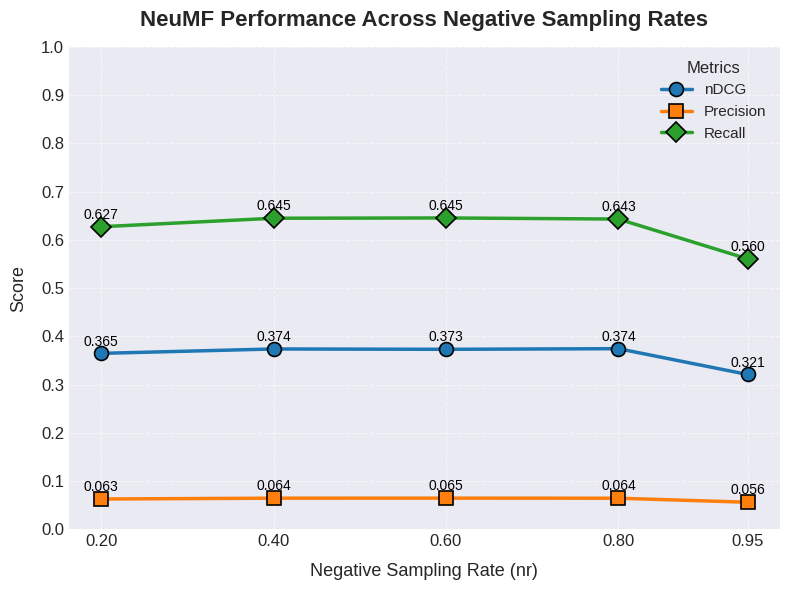

In [ ]:
plt.figure(figsize=(8, 6))

markers = {
    "nDCG": "o",
    "Precision": "s",
    "Recall": "D"
}

for metric in ["nDCG", "Precision", "Recall"]:
    plt.plot(
        df["nr"],
        df[metric],
        marker=markers[metric],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=1.2,
        linewidth=2.5,
        label=metric
    )

    for x, y in zip(df["nr"], df[metric]):
        plt.text(
            x, y + 0.01,
            f"{y:.3f}",
            ha="center", va="bottom",
            fontsize=10,
            fontweight="medium",
            color="black"
        )

plt.title("NeuMF Performance Across Negative Sampling Rates", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Negative Sampling Rate (nr)", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)

plt.xticks(df["nr"], fontsize=12, fontweight="medium")
plt.yticks(np.arange(0, 1.05, 0.1), fontsize=12, fontweight="medium")  # clearer & evenly spaced y-ticks
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(title="Metrics", fontsize=11, title_fontsize=12, loc="best")

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/metrics_vs_neg_samplerate_combined.png", dpi=300)
plt.show()


# Multiple TopK

In [7]:
data = {
    "TopK": [5]*5 + [10]*5 + [20]*5 + [50]*5,
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20]*4,
    "HitRate": [
        0.4018211920529801, 0.46605960264900664, 0.4690397350993378, 0.469205298013245, 0.4471854304635762,
        0.5604304635761589, 0.643046357615894, 0.645364238410596, 0.6447019867549669, 0.6271523178807947,
        0.7208609271523179, 0.802317880794702, 0.8082781456953643, 0.8092715231788079, 0.7933774834437086,
        0.9183774834437086, 0.9600993377483443, 0.9586092715231788, 0.9587748344370861, 0.9544701986754967
    ],
    "nDCG": [
        0.2697065552100979, 0.3172547265543212, 0.3160255669227221, 0.3169896272405769, 0.3063505371459467,
        0.3208008811891443, 0.3743937717980421, 0.37306293288034487, 0.3737129001338871, 0.36458616168972874,
        0.361396341939741, 0.4146885684133939, 0.4144972928330808, 0.41558253601350625, 0.40681330024589923,
        0.4008453517855019, 0.4463834966894295, 0.44479043540765123, 0.4457995335409477, 0.4391717788818347
    ],
    "Precision": [
        0.08036423841059603, 0.09321192052980132, 0.09380794701986755, 0.09384105960264902, 0.08943708609271524,
        0.056043046357615894, 0.06430463576158942, 0.0645364238410596, 0.06447019867549669, 0.06271523178807947,
        0.0360430463576159, 0.0401158940397351, 0.040413907284768215, 0.0404635761589404, 0.03966887417218543,
        0.01836754966887417, 0.01920198675496689, 0.019172185430463576, 0.019175496688741724, 0.019089403973509934
    ],
    "Recall": [
        0.4018211920529801, 0.46605960264900664, 0.4690397350993378, 0.469205298013245, 0.4471854304635762,
        0.5604304635761589, 0.643046357615894, 0.645364238410596, 0.6447019867549669, 0.6271523178807947,
        0.7208609271523179, 0.802317880794702, 0.8082781456953643, 0.8092715231788079, 0.7933774834437086,
        0.9183774834437086, 0.9600993377483443, 0.9586092715231788, 0.9587748344370861, 0.9544701986754967
    ]
}

df = pd.DataFrame(data)
df

,TopK,nr,HitRate,nDCG,Precision,Recall
0,5,0.95,0.401821,0.269707,0.080364,0.401821
1,5,0.80,0.466060,0.317255,0.093212,0.466060
2,5,0.60,0.469040,0.316026,0.093808,0.469040
3,5,0.40,0.469205,0.316990,0.093841,0.469205
4,5,0.20,0.447185,0.306351,0.089437,0.447185
5,10,0.95,0.560430,0.320801,0.056043,0.560430
6,10,0.80,0.643046,0.374394,0.064305,0.643046
7,10,0.60,0.645364,0.373063,0.064536,0.645364
8,10,0.40,0.644702,0.373713,0.064470,0.644702
9,10,0.20,0.627152,0.364586,0.062715,0.627152


# EL2N Data

In [3]:
# topk@5:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.40380794701986755,0.2711029130466559,0.08076158940397352,0.40380794701986755

#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.46225165562913906,0.31290647637553826,0.09245033112582782,0.46225165562913906

#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.4541390728476821,0.30695549148057916,0.09082781456953642,0.4541390728476821

#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.4503311258278146,0.3035201196113175,0.09006622516556291,0.4503311258278146


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.4425496688741722,0.29657372848985114,0.08850993377483445,0.4425496688741722




# topk@10:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.5630794701986755,0.3223147528819573,0.056307947019867556,0.5630794701986755


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.6422185430463576,0.3713227446771613,0.06422185430463577,0.6422185430463576


#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.6339403973509934,0.3648858666782661,0.06339403973509934,0.6339403973509934


#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.6422185430463576,0.3656594449072995,0.06422185430463577,0.6422185430463576


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.6258278145695364,0.35577307218853377,0.06258278145695365,0.6258278145695364





# topk@20:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.7221854304635762,0.36252476594186034,0.03610927152317881,0.7221854304635762


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.8049668874172186,0.4126013398055079,0.04024834437086093,0.8049668874172186


#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.8056291390728477,0.40845052819052374,0.04028145695364239,0.8056291390728477


#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.8052980132450331,0.40692244385480636,0.040264900662251656,0.8052980132450331


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.7950331125827814,0.3987878383070333,0.03975165562913908,0.7950331125827814





# topk@50:
#         nr = 0.95
#         HitRate,nDCG,Precision,Recall
#         0.9127483443708609,0.40055978583986795,0.01825496688741722,0.9127483443708609


#         nr = 0.80
#         HitRate,nDCG,Precision,Recall
#         0.9564569536423841,0.44308802036539396,0.019129139072847683,0.9564569536423841

#         nr = 0.60
#         HitRate,nDCG,Precision,Recall
#         0.9564569536423841,0.4388790165214627,0.019129139072847683,0.9564569536423841

#         nr = 0.40
#         HitRate,nDCG,Precision,Recall
#         0.9614238410596027,0.4383648641365673,0.019228476821192053,0.9614238410596027


#         nr = 0.20
#         HitRate,nDCG,Precision,Recall
#         0.9551324503311258,0.4309762356005687,0.019102649006622514,0.9551324503311258


data = {
    "TopK": [5]*5 + [10]*5 + [20]*5 + [50]*5,
    "nr": [0.95, 0.80, 0.60, 0.40, 0.20]*4,

    "HitRate": [
        0.40380794701986755, 0.46225165562913906, 0.4541390728476821, 0.4503311258278146, 0.4425496688741722,
        0.5630794701986755,  0.6422185430463576,  0.6339403973509934,  0.6422185430463576,  0.6258278145695364,
        0.7221854304635762,  0.8049668874172186,  0.8056291390728477,  0.8052980132450331,  0.7950331125827814,
        0.9127483443708609,  0.9564569536423841,  0.9564569536423841,  0.9614238410596027,  0.9551324503311258
    ],

    "nDCG": [
        0.2711029130466559,  0.31290647637553826, 0.30695549148057916, 0.3035201196113175,  0.29657372848985114,
        0.3223147528819573,  0.3713227446771613,  0.3648858666782661,  0.3656594449072995,  0.35577307218853377,
        0.36252476594186034, 0.4126013398055079,  0.40845052819052374, 0.40692244385480636, 0.3987878383070333,
        0.40055978583986795, 0.44308802036539396, 0.4388790165214627,  0.4383648641365673,  0.4309762356005687
    ],

    "Precision": [
        0.08076158940397352, 0.09245033112582782, 0.09082781456953642, 0.09006622516556291, 0.08850993377483445,
        0.056307947019867556,0.06422185430463577, 0.06339403973509934, 0.06422185430463577, 0.06258278145695365,
        0.03610927152317881, 0.04024834437086093,  0.04028145695364239,  0.040264900662251656, 0.03975165562913908,
        0.01825496688741722, 0.019129139072847683, 0.019129139072847683,  0.019228476821192053, 0.019102649006622514
    ],

    "Recall": [
        0.40380794701986755, 0.46225165562913906, 0.4541390728476821,  0.4503311258278146,  0.4425496688741722,
        0.5630794701986755,  0.6422185430463576,  0.6339403973509934,  0.6422185430463576,  0.6258278145695364,
        0.7221854304635762,  0.8049668874172186,  0.8056291390728477,  0.8052980132450331,  0.7950331125827814,
        0.9127483443708609,  0.9564569536423841,  0.9564569536423841,  0.9614238410596027,  0.9551324503311258
    ]
}

df = pd.DataFrame(data)
df

,TopK,nr,HitRate,nDCG,Precision,Recall
0,5,0.95,0.403808,0.271103,0.080762,0.403808
1,5,0.80,0.462252,0.312906,0.092450,0.462252
2,5,0.60,0.454139,0.306955,0.090828,0.454139
3,5,0.40,0.450331,0.303520,0.090066,0.450331
4,5,0.20,0.442550,0.296574,0.088510,0.442550
5,10,0.95,0.563079,0.322315,0.056308,0.563079
6,10,0.80,0.642219,0.371323,0.064222,0.642219
7,10,0.60,0.633940,0.364886,0.063394,0.633940
8,10,0.40,0.642219,0.365659,0.064222,0.642219
9,10,0.20,0.625828,0.355773,0.062583,0.625828


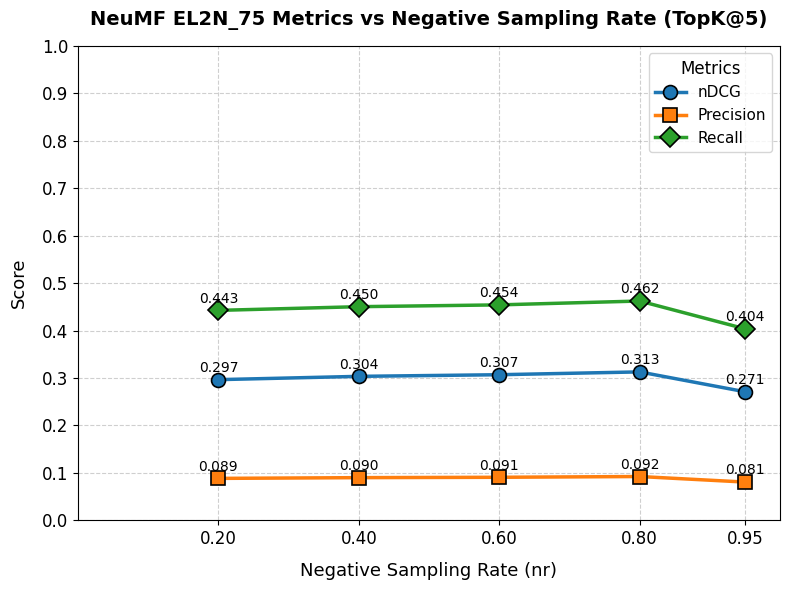

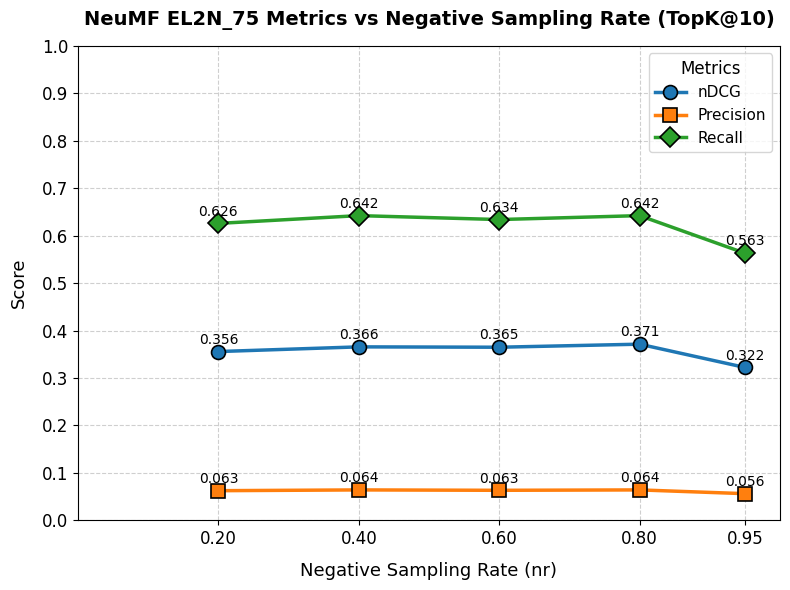

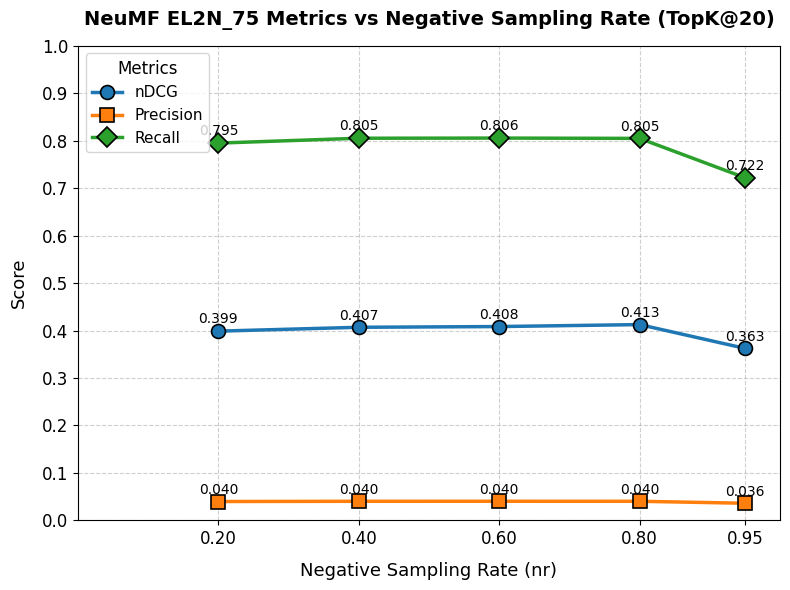

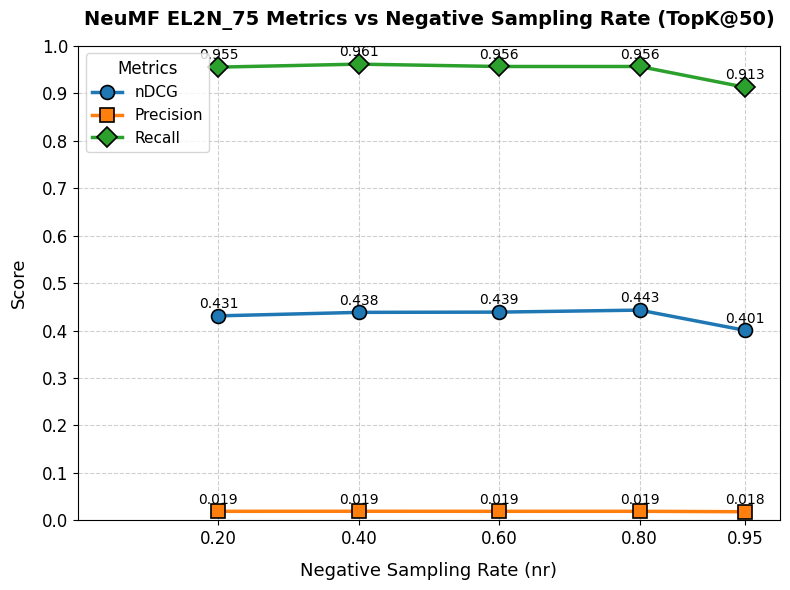

In [ ]:
markers = {
    "nDCG": "o",
    "Precision": "s",
    "Recall": "D"
}

# save_path_base = "/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/EL2N_75_results"

for topk, group in df.groupby("TopK"):
    plt.figure(figsize=(8, 6))
    
    for metric in ["nDCG", "Precision", "Recall"]:
        plt.plot(
            group["nr"],
            group[metric],
            marker=markers[metric],
            markersize=10,
            markeredgecolor="black",
            markeredgewidth=1.2,
            linewidth=2.5,
            label=metric
        )
        
        for x, y in zip(group["nr"], group[metric]):
            plt.text(
                x, y + 0.01,
                f"{y:.3f}",
                ha="center", va="bottom",
                fontsize=10,
                fontweight="medium",
                color="black"
            )

    plt.title(f"NeuMF EL2N_75 Metrics vs Negative Sampling Rate (TopK@{topk})",
              fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Negative Sampling Rate (nr)", fontsize=13, labelpad=10)
    plt.ylabel("Score", fontsize=13, labelpad=10)

    plt.xticks(group["nr"], fontsize=12, fontweight="medium")
    plt.yticks(np.arange(0, 1.05, 0.1), fontsize=12, fontweight="medium")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.legend(title="Metrics", fontsize=11, title_fontsize=12, loc="best")

    plt.tight_layout()
    # plt.savefig(f"{save_path_base}/NeuMF_TopK@{topk}_metrics_vs_nr.png", dpi=300)
    plt.show()


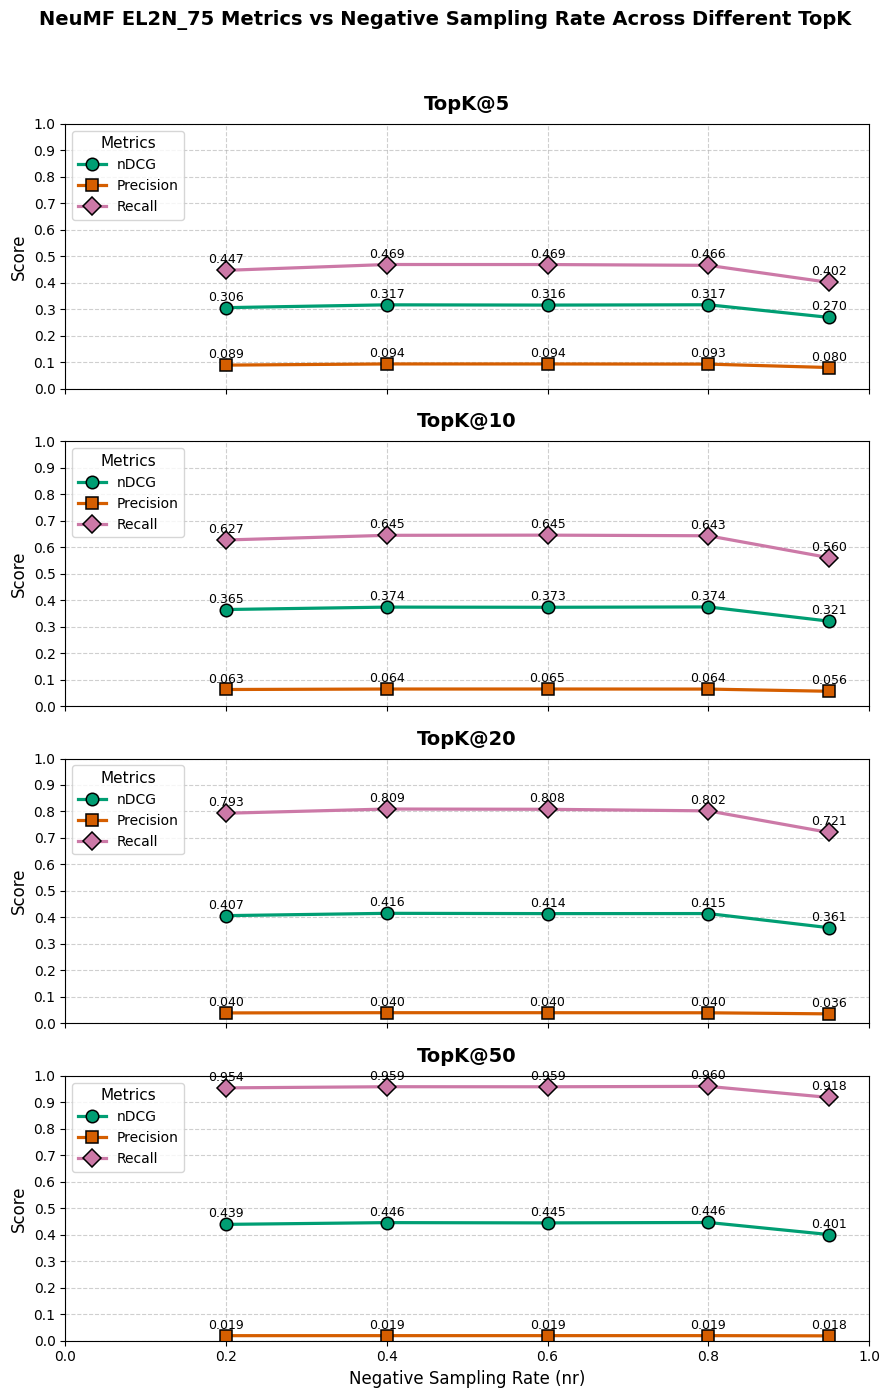

In [8]:
markers = {"nDCG": "o", "Precision": "s", "Recall": "D"}
colors = {"nDCG": "#009E73", "Precision": "#D55E00", "Recall": "#CC79A7"}
metrics = ["nDCG", "Precision", "Recall"]
topks = [5, 10, 20, 50]

fig, axes = plt.subplots(len(topks), 1, figsize=(9, 14), sharex=True)
fig.subplots_adjust(hspace=0.3)


for idx, topk in enumerate(topks):
    group = df[df["TopK"] == topk]
    ax = axes[idx]
    
    for metric in metrics:
        ax.plot(
            group["nr"],
            group[metric],
            marker=markers[metric],
            color=colors[metric],
            markersize=9,
            markeredgecolor="black",
            markeredgewidth=1.1,
            linewidth=2.3,
            label=metric
        )
        
        for x, y in zip(group["nr"], group[metric]):
            ax.text(x, y + 0.015, f"{y:.3f}",
                    ha="center", va="bottom", fontsize=9, fontweight="medium")
    
    ax.set_title(f"TopK@{topk}", fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.05, 0.1))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Metrics", fontsize=10, title_fontsize=11, loc="upper left")

axes[-1].set_xlabel("Negative Sampling Rate (nr)", fontsize=12)
plt.suptitle("NeuMF EL2N_75 Metrics vs Negative Sampling Rate Across Different TopK", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig("/home/dhruv/Documents/NCF/NCF_Recommendation/Experiments_results/NeuMF_All_TopK_vs_NR.png", dpi=300)
plt.show()

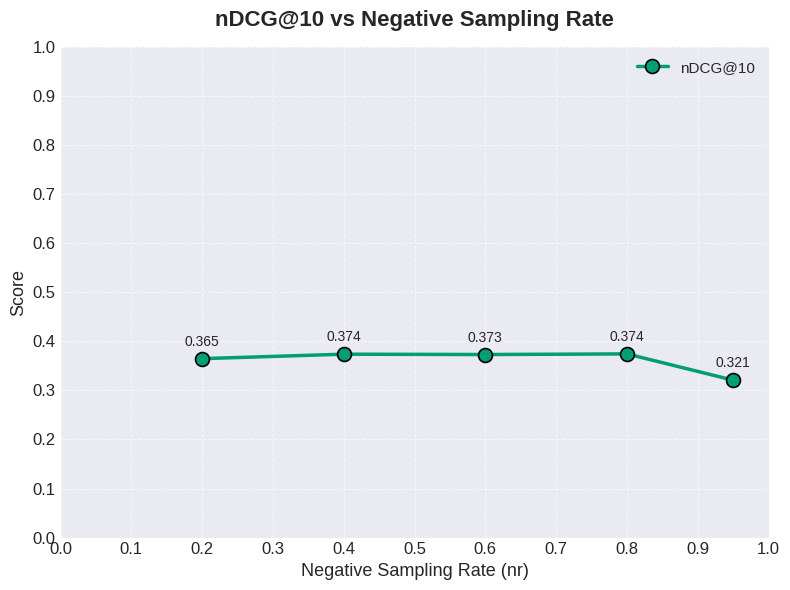

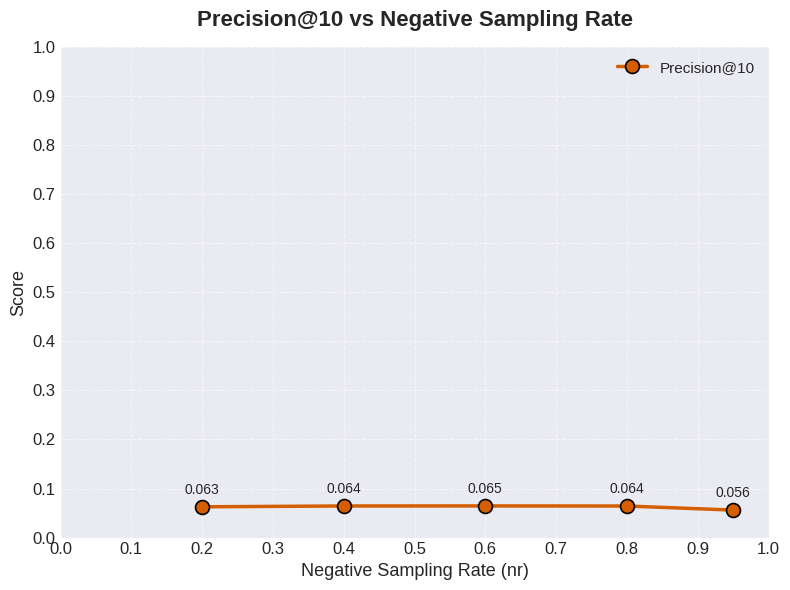

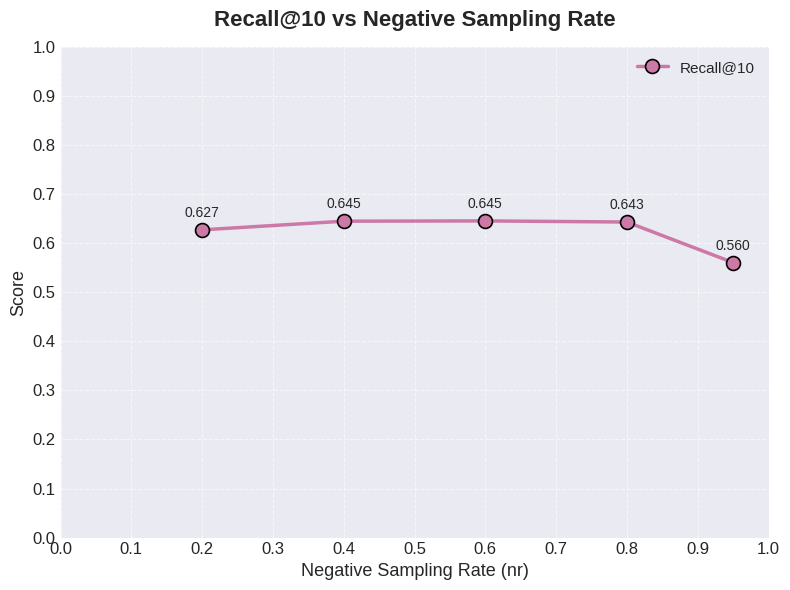

In [ ]:
metrics = ["nDCG", "Precision", "Recall"]
colors = {
    "nDCG": "#009E73",
    "Precision": "#D55E00",
    "Recall": "#CC79A7"
}

for metric in metrics:
    plt.figure(figsize=(8, 6))

    plt.plot(
        df["nr"],
        df[metric],
        marker='o',
        color=colors[metric],
        markersize=10,
        markeredgecolor='black',
        markeredgewidth=1.2,
        linewidth=2.5,
        label=f"{metric}@10"
    )

    for x, y in zip(df["nr"], df[metric]):
        plt.text(
            x, y + 0.02, f"{y:.3f}",
            ha='center', va='bottom',
            fontsize=10, fontweight='medium'
        )

    # Title and labels
    plt.title(f"{metric}@10 vs Negative Sampling Rate", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Negative Sampling Rate (nr)", fontsize=13)
    plt.ylabel("Score", fontsize=13)

    # Axis limits and ticks
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks([i/10 for i in range(0, 11)], fontsize=12, fontweight="medium")
    plt.yticks([i/10 for i in range(0, 11)], fontsize=12, fontweight="medium")

    # Grid and legend
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()

    # Save each plot separately
    # plt.savefig(f"plots/{metric.lower()}_vs_neg_samplerate.png", dpi=300)
    plt.show()


In [1]:
EL2N_result = """

El2n_40: We only take 40% of the negative data

Execution Time: 5833.29 seconds
CO₂ Emitted: 0.000239 kg
Total Time: 11011.72s
Total Co2 Emitted: 0.038094 kg
Result Of Model EL2N 40 :

Topk 5

{'HitRate': 0.376158940397351, 'nDCG': 0.2685436201840645, 'Precision': 0.0752317880794702, 'Recall': 0.376158940397351}


Topk 10

{'HitRate': 0.541887417218543, 'nDCG': 0.32195136209369213, 'Precision': 0.054188741721854304, 'Recall': 0.541887417218543}


Topk 20

{'HitRate': 0.7160596026490066, 'nDCG': 0.36587246343754026, 'Precision': 0.035802980132450334, 'Recall': 0.7160596026490066}

Topk 50

{'HitRate': 0.9337748344370861, 'nDCG': 0.409455444874626, 'Precision': 0.01867549668874172, 'Recall': 0.9337748344370861}



El2n_30: We only take 30% of the negative data
Execution Time: 5470.46 seconds
CO₂ Emitted: 0.000223 kg
Total Time: 10648.89 s
Total Co2 Emitted: 0.038078 kg


Result Of Model EL2N 30 :

Topk 5

{'HitRate': 0.3920529801324503, 'nDCG': 0.2613580269515502, 'Precision': 0.07841059602649007, 'Recall': 0.3920529801324503}

Topk 10

{'HitRate': 0.569205298013245, 'nDCG': 0.3183835649259984, 'Precision': 0.056920529801324504, 'Recall': 0.569205298013245}

Topk 20

{'HitRate': 0.7427152317880795, 'nDCG': 0.36219103961442156, 'Precision': 0.03713576158940397, 'Recall': 0.7427152317880795}

Topk 50

{'HitRate': 0.9397350993377483, 'nDCG': 0.4017555203102832, 'Precision': 0.018794701986754966, 'Recall': 0.9397350993377483}



El2n_25: We only take 25% of the negative data
Execution Time: 5231.98 seconds
CO₂ Emitted: 0.000211 kg
Total Time: 10410.41 s
Total Co2 Emitted: 0.038066 kg

Result Of Model EL2N 25 :

Topk 5

{'HitRate': 0.3975165562913907, 'nDCG': 0.266616702503032, 'Precision': 0.07950331125827816, 'Recall': 0.3975165562913907}


Topk 10

{'HitRate': 0.5774834437086093, 'nDCG': 0.32462442971833094, 'Precision': 0.05774834437086093, 'Recall': 0.5774834437086093}


Topk 20

{'HitRate': 0.7528145695364239, 'nDCG': 0.36892639106063, 'Precision': 0.0376407284768212, 'Recall': 0.7528145695364239}


Topk 50

{'HitRate': 0.9402317880794702, 'nDCG': 0.40658586700893273, 'Precision': 0.018804635761589403, 'Recall': 0.9402317880794702}



El2n_20: We only take20% of the negative data
Execution Time: 4937.79 seconds
CO₂ Emitted: 0.000200 kg
Total Time: 10116.22 s
Total Co2 Emitted: 0.038055 kg

Result Of Model EL2N 20 :

Topk 5


{'HitRate': 0.4109271523178808, 'nDCG': 0.274936685977285, 'Precision': 0.08218543046357617, 'Recall': 0.4109271523178808}

Topk 10

{'HitRate': 0.5905629139072848, 'nDCG': 0.33289738395383073, 'Precision': 0.05905629139072848, 'Recall': 0.5905629139072848}

Topk 20

{'HitRate': 0.7649006622516556, 'nDCG': 0.3769955135572414, 'Precision': 0.03824503311258278, 'Recall': 0.7649006622516556}

Topk 50

{'HitRate': 0.9364238410596026, 'nDCG': 0.4115378120652127, 'Precision': 0.018728476821192053, 'Recall': 0.9364238410596026}




El2n_15: We only take15% of the negative data
Execution Time: 4732.42 seconds
CO₂ Emitted: 0.000192 kg
Total Time: 9910.85 s
Total Co2 Emitted: 0.038047 kg

Result Of Model EL2N 15 :

Topk 5

{'HitRate': 0.41821192052980133, 'nDCG': 0.282784624362601, 'Precision': 0.08364238410596027, 'Recall': 0.41821192052980133}

Topk 10

{'HitRate': 0.6023178807947019, 'nDCG': 0.34252976003013635, 'Precision': 0.0602317880794702, 'Recall': 0.6023178807947019}

Topk 20

{'HitRate': 0.7697019867549669, 'nDCG': 0.384954931743707, 'Precision': 0.038485099337748345, 'Recall': 0.7697019867549669}

Topk 50

{'HitRate': 0.9370860927152318, 'nDCG': 0.41869756818870885, 'Precision': 0.018741721854304637, 'Recall': 0.9370860927152318}


"""


EL2N_result

"\n\nEl2n_40: We only take 40% of the negative data\n\nExecution Time: 5833.29 seconds\nCO₂ Emitted: 0.000239 kg\nTotal Time: 11011.72s\nTotal Co2 Emitted: 0.038094 kg\nResult Of Model EL2N 40 :\n\nTopk 5\n\n{'HitRate': 0.376158940397351, 'nDCG': 0.2685436201840645, 'Precision': 0.0752317880794702, 'Recall': 0.376158940397351}\n\n\nTopk 10\n\n{'HitRate': 0.541887417218543, 'nDCG': 0.32195136209369213, 'Precision': 0.054188741721854304, 'Recall': 0.541887417218543}\n\n\nTopk 20\n\n{'HitRate': 0.7160596026490066, 'nDCG': 0.36587246343754026, 'Precision': 0.035802980132450334, 'Recall': 0.7160596026490066}\n\nTopk 50\n\n{'HitRate': 0.9337748344370861, 'nDCG': 0.409455444874626, 'Precision': 0.01867549668874172, 'Recall': 0.9337748344370861}\n\n\n\nEl2n_30: We only take 30% of the negative data\nExecution Time: 5470.46 seconds\nCO₂ Emitted: 0.000223 kg\nTotal Time: 10648.89 s\nTotal Co2 Emitted: 0.038078 kg\n\n\nResult Of Model EL2N 30 :\n\nTopk 5\n\n{'HitRate': 0.3920529801324503, 'nDCG':

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load the log file
# with open("performance_log.txt", "r") as f:
#     log = f.read()

# Regex pattern to extract each model block
pattern = r"El2n_(\d+):.*?Total Time: ([\d\.]+).*?Total Co2 Emitted: ([\d\.]+).*?Topk 5.*?\{(.*?)\}.*?Topk 10.*?\{(.*?)\}.*?Topk 20.*?\{(.*?)\}.*?Topk 50.*?\{(.*?)\}"
matches = re.findall(pattern, EL2N_result, re.S)

data = []
for match in matches:
    percent, exec_time, co2, top5, top10, top20, top50 = match
    for topk, metrics in zip([5, 10, 20, 50], [top5, top10, top20, top50]):
        metrics_dict = eval("{" + metrics + "}")
        data.append({
            "Negative_%": int(percent),
            "TopK": topk,
            "Execution_Time_s": float(exec_time),
            "CO2_kg": float(co2),
            **metrics_dict
        })

df = pd.DataFrame(data)

# Sort for better plots
df = df.sort_values(["Negative_%", "TopK"])

print(df.head())


    Negative_%  TopK  Execution_Time_s    CO2_kg   HitRate      nDCG  \
16          15     5           9910.85  0.038047  0.418212  0.282785   
17          15    10           9910.85  0.038047  0.602318  0.342530   
18          15    20           9910.85  0.038047  0.769702  0.384955   
19          15    50           9910.85  0.038047  0.937086  0.418698   
12          20     5          10116.22  0.038055  0.410927  0.274937   

    Precision    Recall  
16   0.083642  0.418212  
17   0.060232  0.602318  
18   0.038485  0.769702  
19   0.018742  0.937086  
12   0.082185  0.410927  


In [3]:
df.head()

,Negative_%,TopK,Execution_Time_s,CO2_kg,HitRate,nDCG,Precision,Recall
16,15,5,9910.85,0.038047,0.418212,0.282785,0.083642,0.418212
17,15,10,9910.85,0.038047,0.602318,0.342530,0.060232,0.602318
18,15,20,9910.85,0.038047,0.769702,0.384955,0.038485,0.769702
19,15,50,9910.85,0.038047,0.937086,0.418698,0.018742,0.937086
12,20,5,10116.22,0.038055,0.410927,0.274937,0.082185,0.410927


In [4]:
df

,Negative_%,TopK,Execution_Time_s,CO2_kg,HitRate,nDCG,Precision,Recall
16,15,5,9910.85,0.038047,0.418212,0.282785,0.083642,0.418212
17,15,10,9910.85,0.038047,0.602318,0.342530,0.060232,0.602318
18,15,20,9910.85,0.038047,0.769702,0.384955,0.038485,0.769702
19,15,50,9910.85,0.038047,0.937086,0.418698,0.018742,0.937086
12,20,5,10116.22,0.038055,0.410927,0.274937,0.082185,0.410927
13,20,10,10116.22,0.038055,0.590563,0.332897,0.059056,0.590563
14,20,20,10116.22,0.038055,0.764901,0.376996,0.038245,0.764901
15,20,50,10116.22,0.038055,0.936424,0.411538,0.018728,0.936424
8,25,5,10410.41,0.038066,0.397517,0.266617,0.079503,0.397517
9,25,10,10410.41,0.038066,0.577483,0.324624,0.057748,0.577483


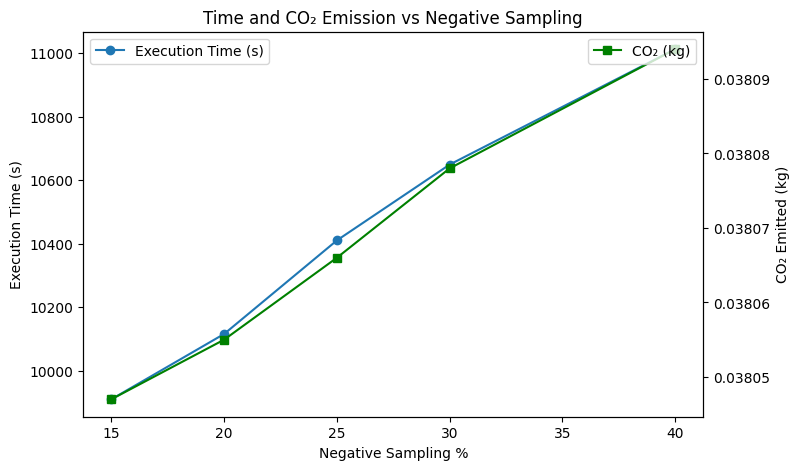

In [5]:
agg = df.groupby("Negative_%")[["Execution_Time_s", "CO2_kg"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

ax1.plot(agg["Negative_%"], agg["Execution_Time_s"], marker="o", label="Execution Time (s)")
ax2.plot(agg["Negative_%"], agg["CO2_kg"], marker="s", color="green", label="CO₂ (kg)")

ax1.set_xlabel("Negative Sampling %")
ax1.set_ylabel("Execution Time (s)")
ax2.set_ylabel("CO₂ Emitted (kg)")
plt.title("Time and CO₂ Emission vs Negative Sampling")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


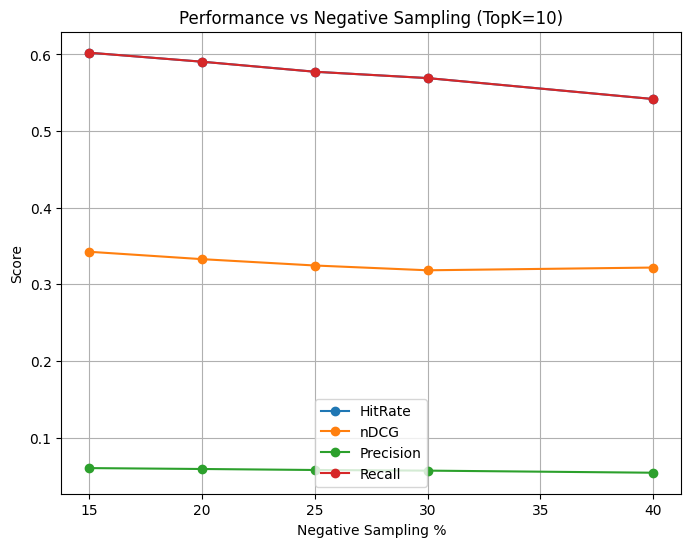

In [6]:
metrics = ["HitRate", "nDCG", "Precision", "Recall"]
plt.figure(figsize=(8,6))

for metric in metrics:
    plt.plot(
        df[df["TopK"] == 10]["Negative_%"],  # choose one TopK for clarity
        df[df["TopK"] == 10][metric],
        marker="o", label=metric
    )

plt.title("Performance vs Negative Sampling (TopK=10)")
plt.xlabel("Negative Sampling %")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


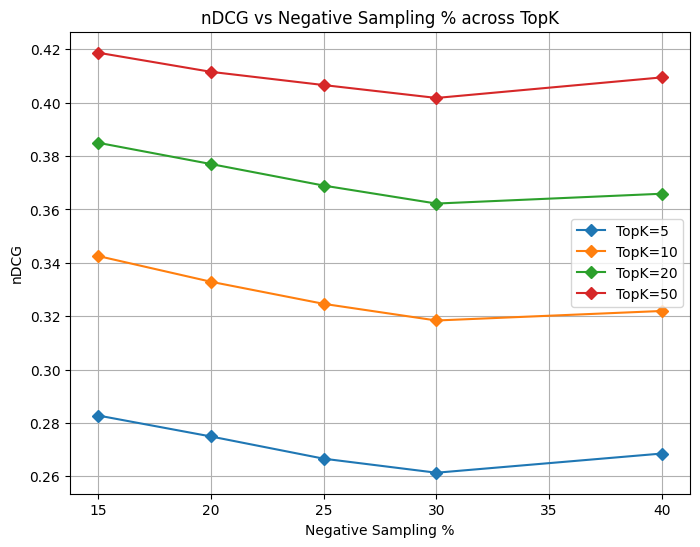

In [7]:
plt.figure(figsize=(8,6))
for topk in [5, 10, 20, 50]:
    plt.plot(
        df[df["TopK"] == topk]["Negative_%"],
        df[df["TopK"] == topk]["nDCG"],
        marker="D", label=f"TopK={topk}"
    )

plt.title("nDCG vs Negative Sampling % across TopK")
plt.xlabel("Negative Sampling %")
plt.ylabel("nDCG")
plt.legend()
plt.grid(True)
plt.show()


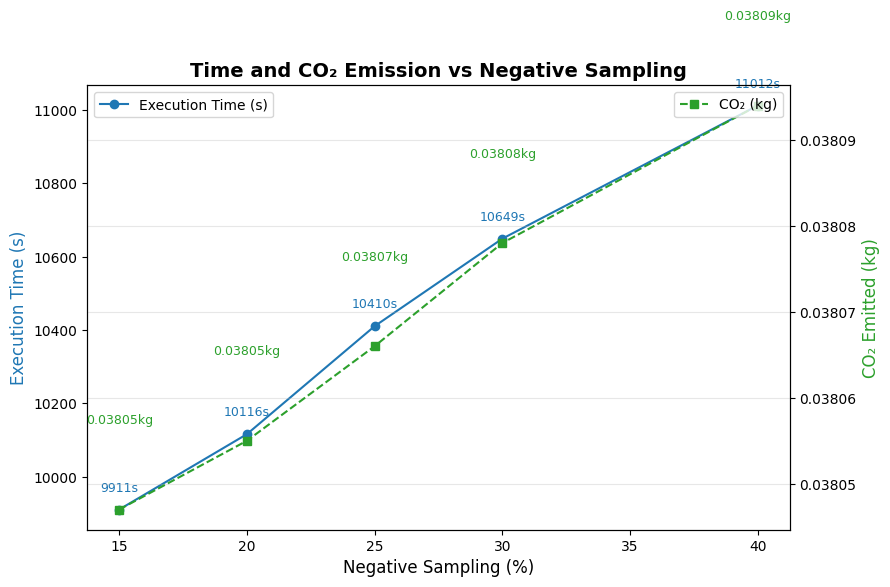

In [9]:
import matplotlib.pyplot as plt

agg = df.groupby("Negative_%")[["Execution_Time_s", "CO2_kg"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(9,6))
ax2 = ax1.twinx()

# Plot lines
ax1.plot(agg["Negative_%"], agg["Execution_Time_s"], "o-", color="tab:blue", label="Execution Time (s)")
ax2.plot(agg["Negative_%"], agg["CO2_kg"], "s--", color="tab:green", label="CO₂ (kg)")

# Add text labels to each point
for i, row in agg.iterrows():
    ax1.text(row["Negative_%"], row["Execution_Time_s"] + 50, f'{row["Execution_Time_s"]:.0f}s',
             color='tab:blue', fontsize=9, ha='center')
    ax2.text(row["Negative_%"], row["CO2_kg"] + 0.00001, f'{row["CO2_kg"]:.5f}kg',
             color='tab:green', fontsize=9, ha='center')

# Labels and formatting
ax1.set_xlabel("Negative Sampling (%)", fontsize=12)
ax1.set_ylabel("Execution Time (s)", color="tab:blue", fontsize=12)
ax2.set_ylabel("CO₂ Emitted (kg)", color="tab:green", fontsize=12)
plt.title("Time and CO₂ Emission vs Negative Sampling", fontsize=14, weight="bold")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


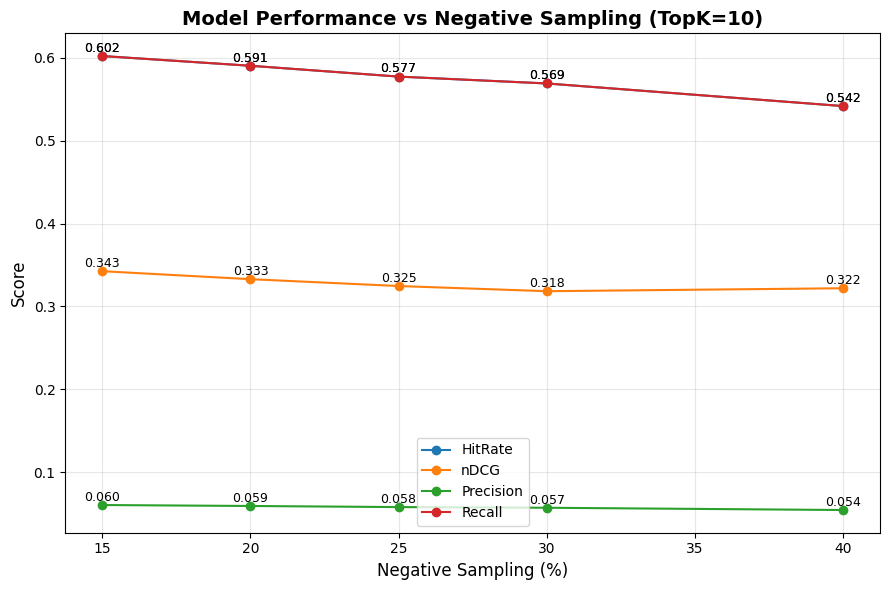

In [17]:
metrics = ["HitRate", "nDCG", "Precision", "Recall"]
plt.figure(figsize=(9,6))

for metric in metrics:
    subset = df[df["TopK"] == 10]
    plt.plot(subset["Negative_%"], subset[metric], marker="o", label=metric)

    # Add value labels
    for x, y in zip(subset["Negative_%"], subset[metric]):
        plt.text(x, y + 0.005, f"{y:.3f}", ha="center", fontsize=9)

plt.title("Model Performance vs Negative Sampling (TopK=10)", fontsize=14, weight="bold")
plt.xlabel("Negative Sampling (%)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


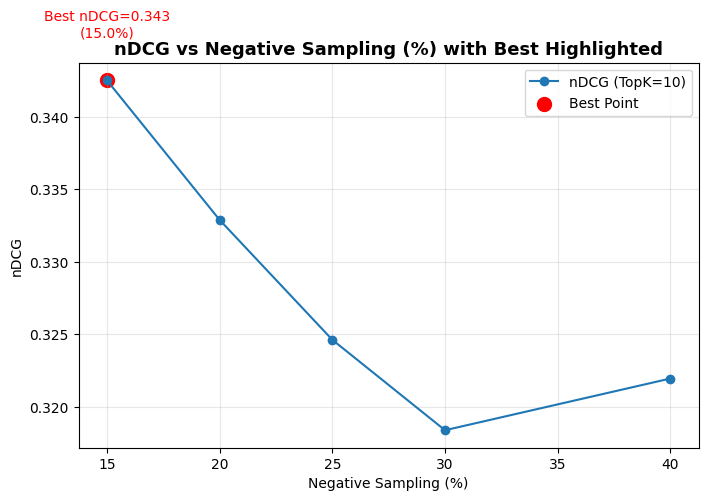

In [18]:
topk = 10
metric = "nDCG"

subset = df[df["TopK"] == topk]
best_idx = subset[metric].idxmax()
best_row = subset.loc[best_idx]

plt.figure(figsize=(8,5))
plt.plot(subset["Negative_%"], subset[metric], "o-", label=f"{metric} (TopK={topk})")
plt.scatter(best_row["Negative_%"], best_row[metric], color="red", s=100, label="Best Point")

# Annotate best point
plt.text(best_row["Negative_%"], best_row[metric] + 0.003,
         f"Best {metric}={best_row[metric]:.3f}\n({best_row['Negative_%']}%)",
         ha="center", fontsize=10, color="red")

plt.title(f"{metric} vs Negative Sampling (%) with Best Highlighted", fontsize=13, weight="bold")
plt.xlabel("Negative Sampling (%)")
plt.ylabel(metric)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


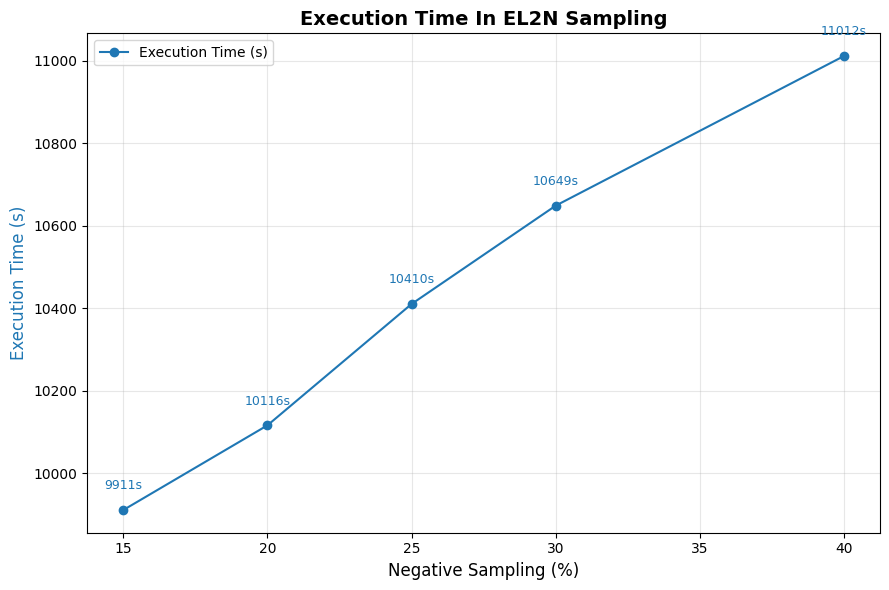

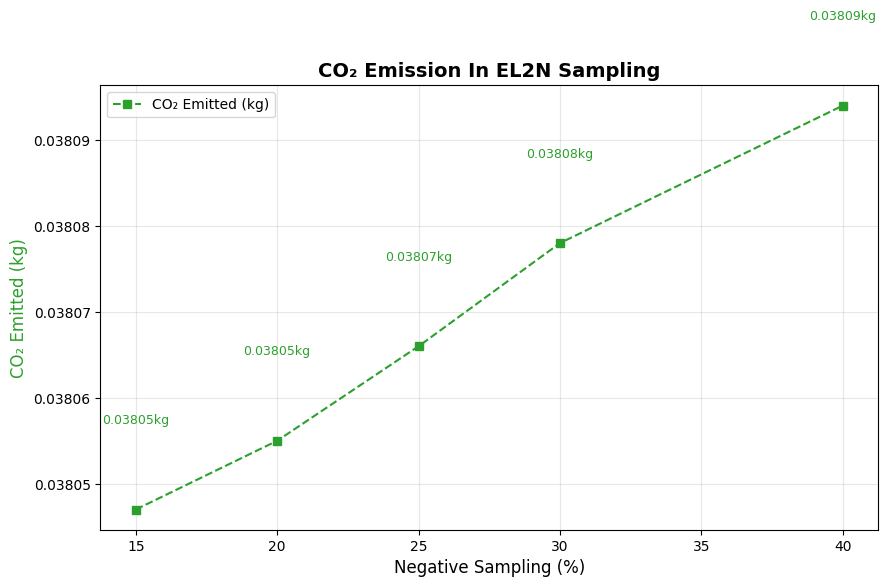

In [11]:
import matplotlib.pyplot as plt

agg = df.groupby("Negative_%")[["Execution_Time_s", "CO2_kg"]].mean().reset_index()

# --- Figure 1: Execution Time ---
plt.figure(figsize=(9, 6))
plt.plot(agg["Negative_%"], agg["Execution_Time_s"], "o-", color="tab:blue", label="Execution Time (s)")
for i, row in agg.iterrows():
    plt.text(row["Negative_%"], row["Execution_Time_s"] + 50, f'{row["Execution_Time_s"]:.0f}s',
             color='tab:blue', fontsize=9, ha='center')
plt.xlabel("Negative Sampling (%)", fontsize=12)
plt.ylabel("Execution Time (s)", fontsize=12, color="tab:blue")
plt.title("Execution Time In EL2N Sampling", fontsize=14, weight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2: CO2 Emission ---
plt.figure(figsize=(9, 6))
plt.plot(agg["Negative_%"], agg["CO2_kg"], "s--", color="tab:green", label="CO₂ Emitted (kg)")
for i, row in agg.iterrows():
    plt.text(row["Negative_%"], row["CO2_kg"] + 0.00001, f'{row["CO2_kg"]:.5f}kg',
             color='tab:green', fontsize=9, ha='center')
plt.xlabel("Negative Sampling (%)", fontsize=12)
plt.ylabel("CO₂ Emitted (kg)", fontsize=12, color="tab:green")
plt.title("CO₂ Emission In EL2N Sampling", fontsize=14, weight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
df

,Negative_%,TopK,Execution_Time_s,CO2_kg,HitRate,nDCG,Precision,Recall
16,15,5,9910.85,0.038047,0.418212,0.282785,0.083642,0.418212
17,15,10,9910.85,0.038047,0.602318,0.342530,0.060232,0.602318
18,15,20,9910.85,0.038047,0.769702,0.384955,0.038485,0.769702
19,15,50,9910.85,0.038047,0.937086,0.418698,0.018742,0.937086
12,20,5,10116.22,0.038055,0.410927,0.274937,0.082185,0.410927
13,20,10,10116.22,0.038055,0.590563,0.332897,0.059056,0.590563
14,20,20,10116.22,0.038055,0.764901,0.376996,0.038245,0.764901
15,20,50,10116.22,0.038055,0.936424,0.411538,0.018728,0.936424
8,25,5,10410.41,0.038066,0.397517,0.266617,0.079503,0.397517
9,25,10,10410.41,0.038066,0.577483,0.324624,0.057748,0.577483


/tmp/ipykernel_1526102/3714274773.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([
/tmp/ipykernel_1526102/3714274773.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Model"], rotation=45, ha='right')
/tmp/ipykernel_1526102/3714274773.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Model"], rotation=45, ha='right')
/tmp/ipykernel_1526102/3714274773.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(

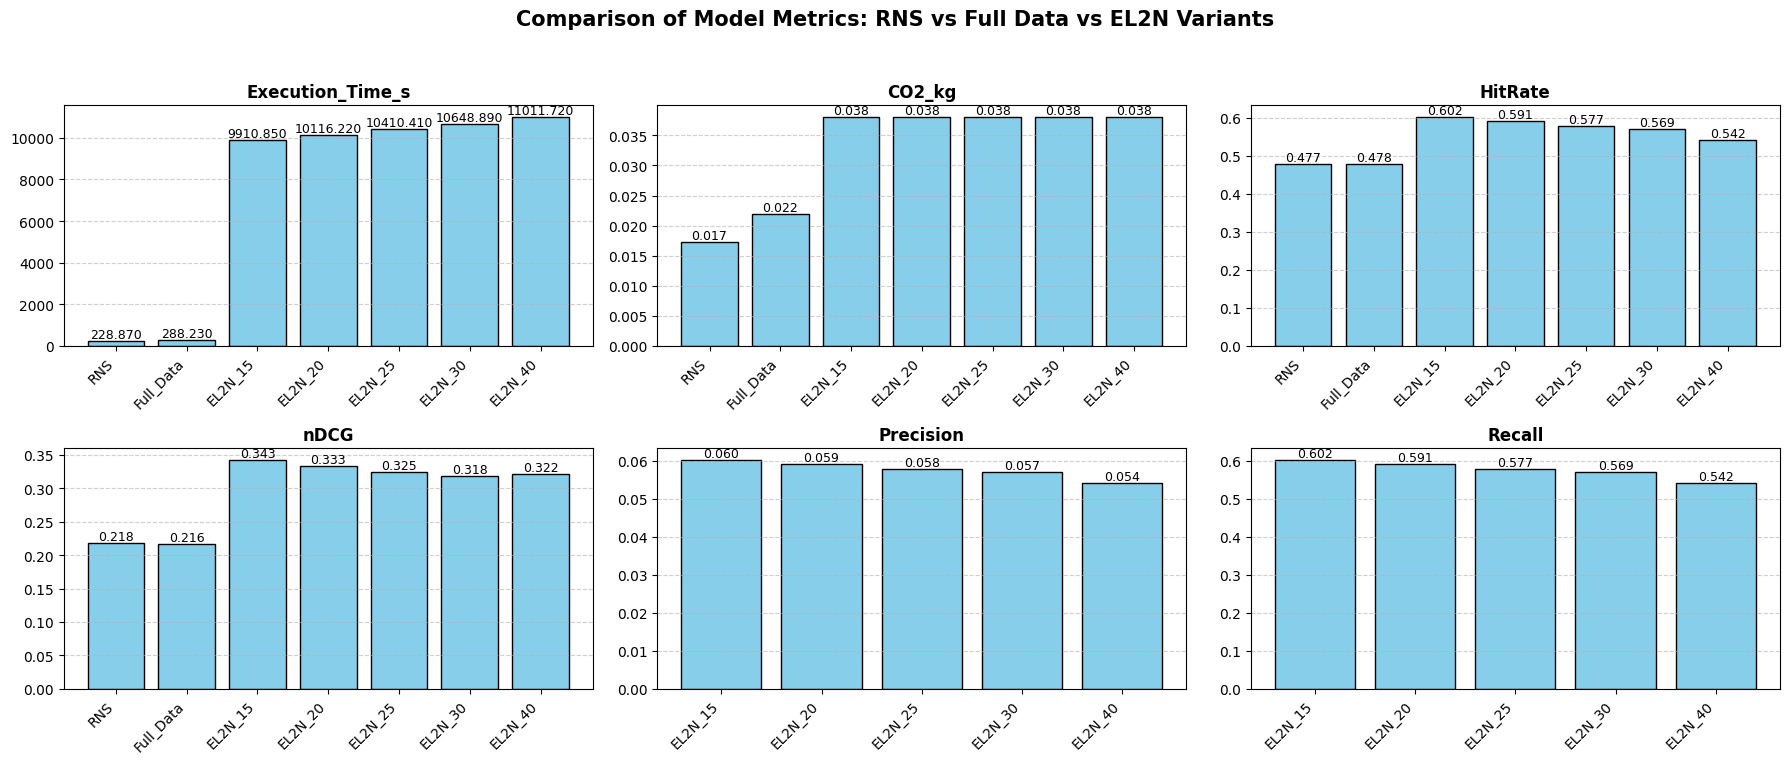

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Define all your model results ---

# RNS Model
rns = {
    "Model": "RNS",
    "Execution_Time_s": 228.87,
    "CO2_kg": 0.017342,
    "HitRate": 0.4773,
    "nDCG": 0.2183,
    "Precision": None,  # not reported
    "Recall": None      # not reported
}

# Full Data Model
full_data = {
    "Model": "Full_Data",
    "Execution_Time_s": 288.23,
    "CO2_kg": 0.0218853,
    "HitRate": 0.4776,
    "nDCG": 0.2163,
    "Precision": None,
    "Recall": None
}

# EL2N Variants
el2n_data = [
    [15, 10, 9910.85, 0.038047, 0.602318, 0.34253, 0.060232, 0.602318],
    [20, 10, 10116.22, 0.038055, 0.590563, 0.332897, 0.059056, 0.590563],
    [25, 10, 10410.41, 0.038066, 0.577483, 0.324624, 0.057748, 0.577483],
    [30, 10, 10648.89, 0.038078, 0.569205, 0.318384, 0.056921, 0.569205],
    [40, 10, 11011.72, 0.038094, 0.541887, 0.321951, 0.054189, 0.541887],
]

el2n_cols = ["Negative_EL2N", "TopK", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]
el2n_df = pd.DataFrame(el2n_data, columns=el2n_cols)
el2n_df["Model"] = "EL2N_" + el2n_df["Negative_EL2N"].astype(str)

# Combine all models
df = pd.concat([
    pd.DataFrame([rns, full_data]),
    el2n_df[["Model", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]]
], ignore_index=True)

# --- Plot setup ---
metrics = ["Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

# --- Plot each metric ---
for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.bar(df["Model"], df[metric], color='skyblue', edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticklabels(df["Model"], rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Annotate each bar with value
    for idx, val in enumerate(df[metric]):
        if pd.notna(val):
            ax.text(idx, val, f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Comparison of Model Metrics: RNS vs Full Data vs EL2N Variants", fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Save summary to text file ---
summary_text = df.to_string(index=False)
with open("model_comparison_summary.txt", "w") as f:
    f.write("=== Model Comparison Summary ===\n\n")
    f.write(summary_text)


/tmp/ipykernel_1526102/505808886.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([


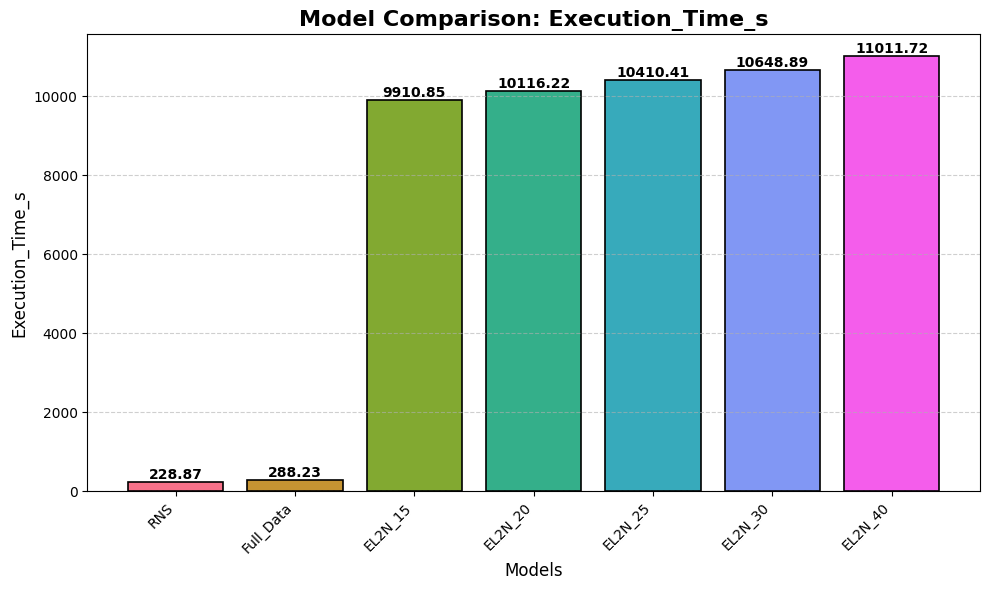

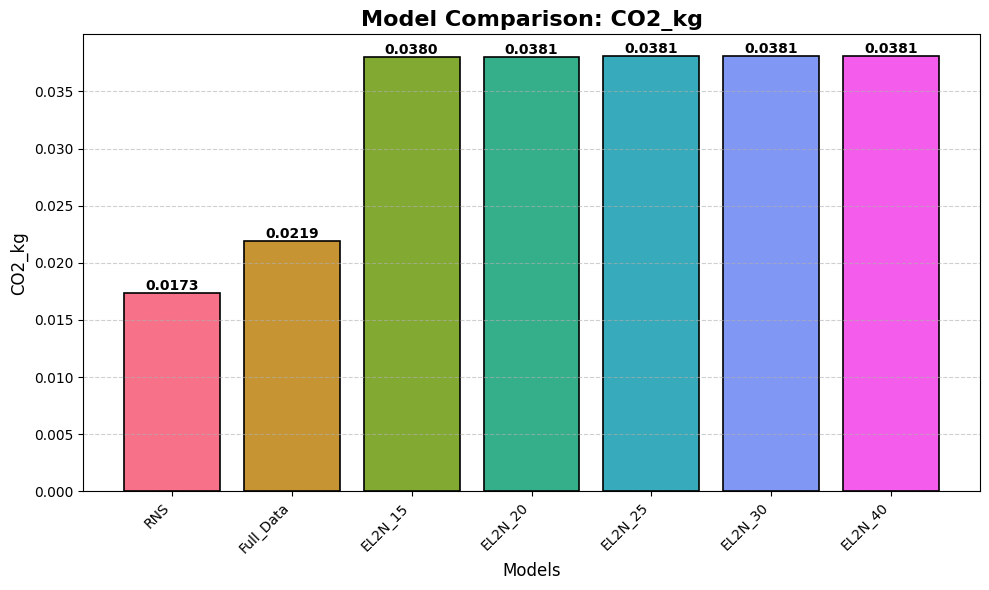

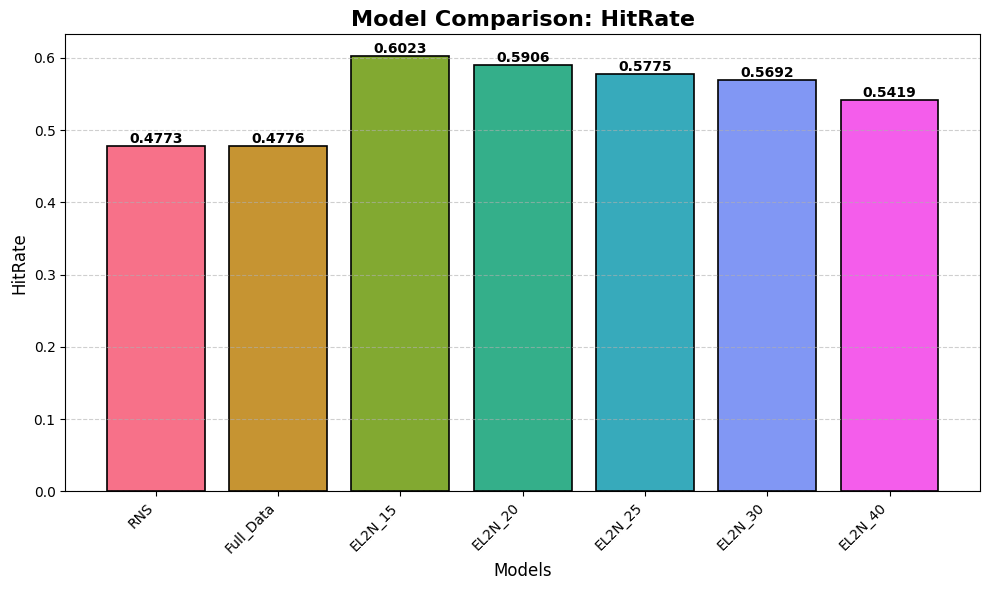

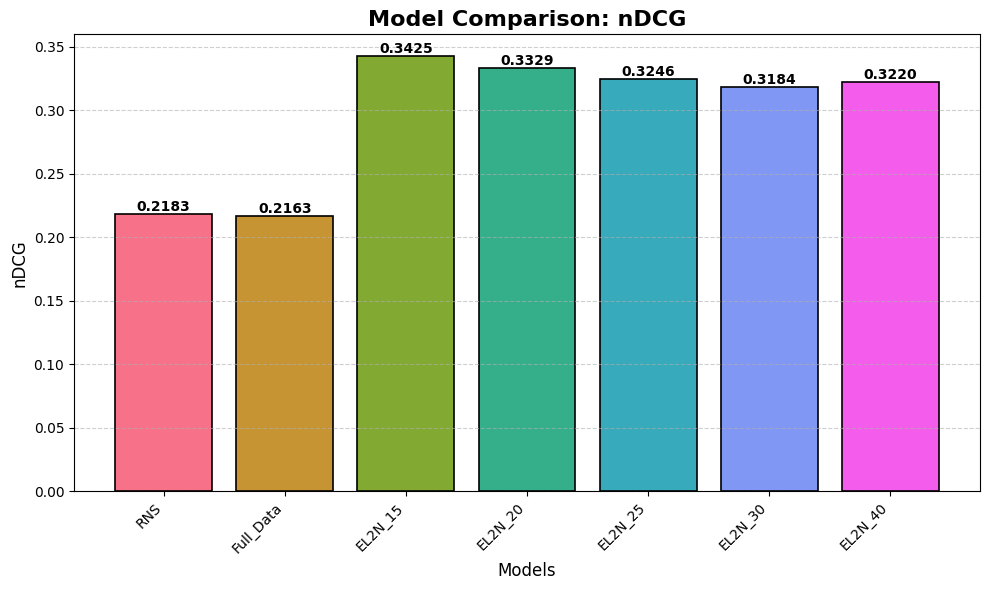

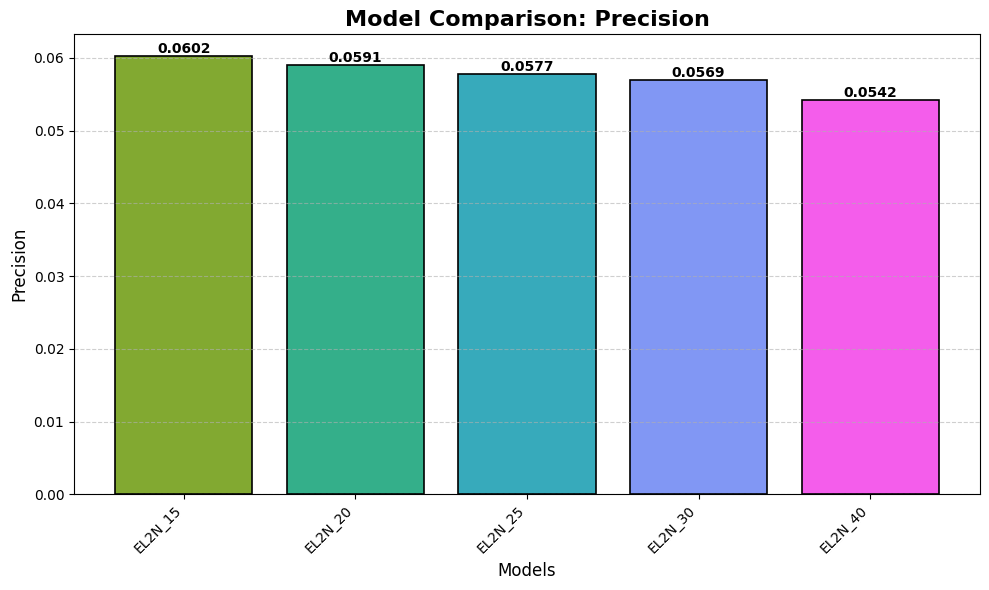

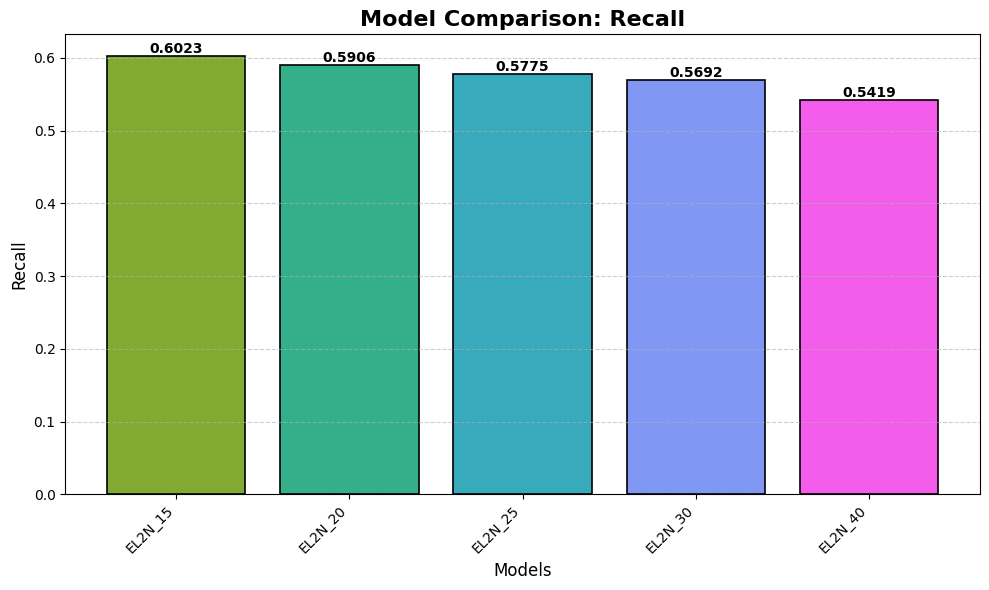

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define all your model results ---

# RNS Model
rns = {
    "Model": "RNS",
    "Execution_Time_s": 228.87,
    "CO2_kg": 0.017342,
    "HitRate": 0.4773,
    "nDCG": 0.2183,
    "Precision": None,
    "Recall": None
}

# Full Data Model
full_data = {
    "Model": "Full_Data",
    "Execution_Time_s": 288.23,
    "CO2_kg": 0.0218853,
    "HitRate": 0.4776,
    "nDCG": 0.2163,
    "Precision": None,
    "Recall": None
}

# EL2N Variants
el2n_data = [
    [15, 10, 9910.85, 0.038047, 0.602318, 0.34253, 0.060232, 0.602318],
    [20, 10, 10116.22, 0.038055, 0.590563, 0.332897, 0.059056, 0.590563],
    [25, 10, 10410.41, 0.038066, 0.577483, 0.324624, 0.057748, 0.577483],
    [30, 10, 10648.89, 0.038078, 0.569205, 0.318384, 0.056921, 0.569205],
    [40, 10, 11011.72, 0.038094, 0.541887, 0.321951, 0.054189, 0.541887],
]

el2n_cols = ["Negative_EL2N", "TopK", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]
el2n_df = pd.DataFrame(el2n_data, columns=el2n_cols)
el2n_df["Model"] = "EL2N_" + el2n_df["Negative_EL2N"].astype(str)

# Combine all models
df = pd.concat([
    pd.DataFrame([rns, full_data]),
    el2n_df[["Model", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]]
], ignore_index=True)

# --- Define metrics and colors ---
metrics = ["Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]
palette = sns.color_palette("husl", len(df))  # bright, distinct colors

# --- Plot each metric separately ---
for metric in metrics:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(df["Model"], df[metric], color=palette, edgecolor="black", linewidth=1.2)
    
    # Title and labels
    plt.title(f"Model Comparison: {metric}", fontsize=16, fontweight="bold")
    plt.xlabel("Models", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.xticks(rotation=45, ha="right")

    # Add value annotations above bars
    for bar, val in zip(bars, df[metric]):
        if pd.notna(val):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.4f}" if val < 1 else f"{val:.2f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold"
            )
    
    # Adjust layout and show
    plt.tight_layout()
    plt.show()

# --- Save summary to text file ---
summary_text = df.to_string(index=False)
with open("model_comparison_summary.txt", "w") as f:
    f.write("=== Model Comparison Summary ===\n\n")
    f.write(summary_text)


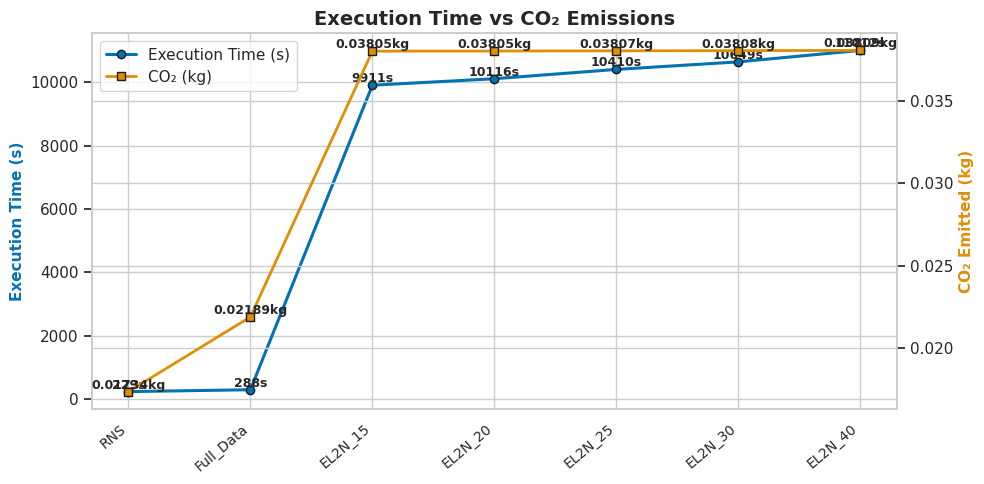

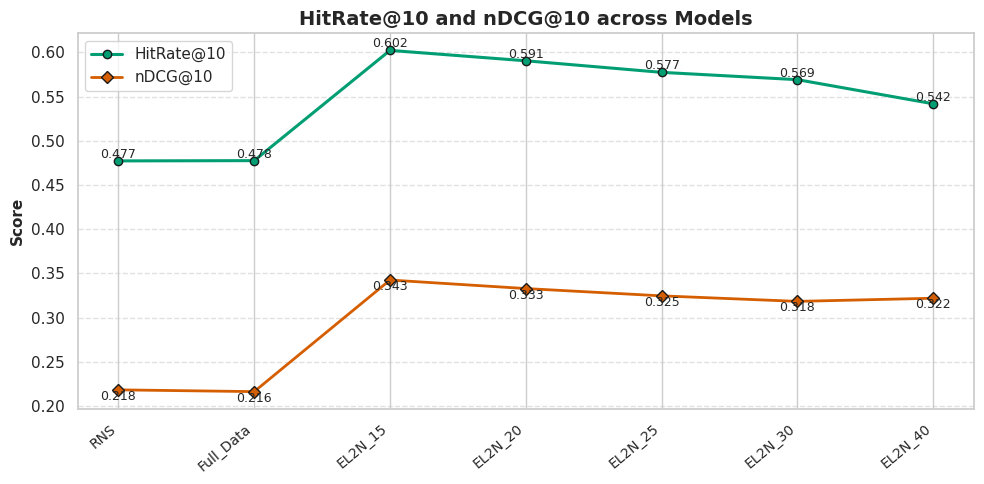

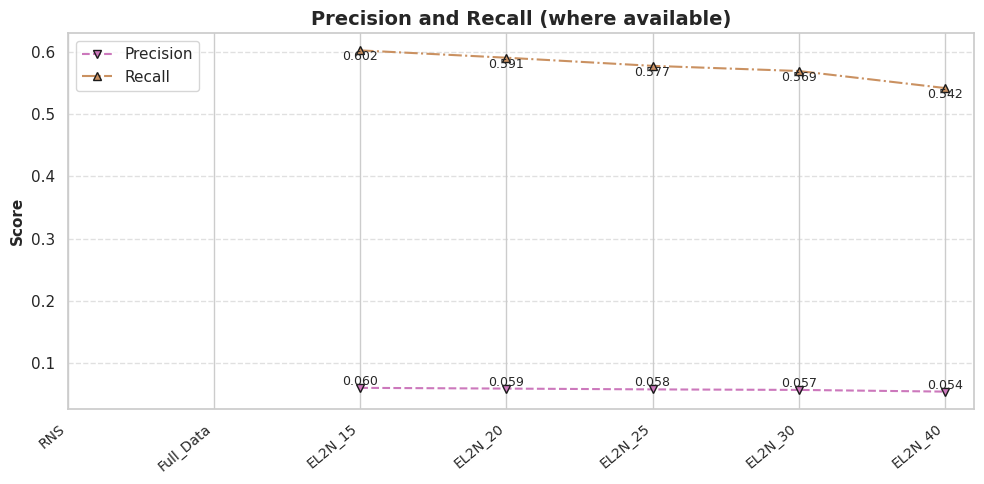

Plots created and summary saved to 'model_comparison_summary.txt'.


In [15]:
rns = {
    "Model": "RNS",
    "Execution_Time_s": 228.87,
    "CO2_kg": 0.017342,
    "HitRate": 0.4773,
    "nDCG": 0.2183,
    "Precision": np.nan,
    "Recall": np.nan
}

full_data = {
    "Model": "Full_Data",
    "Execution_Time_s": 288.23,
    "CO2_kg": 0.0218853,
    "HitRate": 0.4776,
    "nDCG": 0.2163,
    "Precision": np.nan,
    "Recall": np.nan
}

el2n_data = [
    [15, 10, 9910.85, 0.038047, 0.602318, 0.34253, 0.060232, 0.602318],
    [20, 10, 10116.22, 0.038055, 0.590563, 0.332897, 0.059056, 0.590563],
    [25, 10, 10410.41, 0.038066, 0.577483, 0.324624, 0.057748, 0.577483],
    [30, 10, 10648.89, 0.038078, 0.569205, 0.318384, 0.056921, 0.569205],
    [40, 10, 11011.72, 0.038094, 0.541887, 0.321951, 0.054189, 0.541887],
]

el2n_cols = ["Negative_EL2N", "TopK", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]
el2n_df = pd.DataFrame(el2n_data, columns=el2n_cols)
el2n_df["Model"] = "EL2N_" + el2n_df["Negative_EL2N"].astype(int).astype(str)

# Combine
df = pd.concat([
    pd.DataFrame([rns, full_data]),
    el2n_df[["Model", "Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]]
], ignore_index=True)

# Ensure numeric types and stable order
metrics = ["Execution_Time_s", "CO2_kg", "HitRate", "nDCG", "Precision", "Recall"]
for m in metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# Keep model order as given
model_order = df["Model"].tolist()
x = np.arange(len(model_order))  # numeric x positions for plotting

# Style: professional and colorblind-friendly
sns.set_theme(style="whitegrid")
palette = sns.color_palette("colorblind")  # professional, accessible palette

# ---------- 1) Execution Time (line) + CO2 (line, secondary y-axis) ----------
fig, ax_time = plt.subplots(figsize=(10, 5))
ax_co2 = ax_time.twinx()

# Lines with markers
ax_time.plot(x, df["Execution_Time_s"], marker="o", linewidth=2.2,
             label="Execution Time (s)", color=palette[0], markeredgecolor="k")
ax_co2.plot(x, df["CO2_kg"], marker="s", linewidth=2.0,
            label="CO₂ (kg)", color=palette[1], markeredgecolor="k")

# Annotations
for xi, t, c in zip(x, df["Execution_Time_s"], df["CO2_kg"]):
    if not np.isnan(t):
        ax_time.text(xi, t, f"{t:.0f}s", ha="center", va="bottom", fontsize=9, fontweight="semibold")
    if not np.isnan(c):
        ax_co2.text(xi, c, f"{c:.5f}kg", ha="center", va="bottom", fontsize=9, fontweight="semibold")

# Labels and styling
ax_time.set_xticks(x)
ax_time.set_xticklabels(model_order, rotation=40, ha="right", fontsize=10)
ax_time.set_ylabel("Execution Time (s)", color=palette[0], fontsize=11, fontweight="bold")
ax_co2.set_ylabel("CO₂ Emitted (kg)", color=palette[1], fontsize=11, fontweight="bold")
ax_time.set_title("Execution Time vs CO₂ Emissions", fontsize=14, fontweight="bold")

# Legends: combine handles
handles_time, labels_time = ax_time.get_legend_handles_labels()
handles_co2, labels_co2 = ax_co2.get_legend_handles_labels()
ax_time.legend(handles_time + handles_co2, labels_time + labels_co2, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

# ---------- 2) HitRate and nDCG (line plot, same axes) ----------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, df["HitRate"], marker="o", linewidth=2.2, label="HitRate@10", color=palette[2], markeredgecolor="k")
ax.plot(x, df["nDCG"], marker="D", linewidth=2.0, label="nDCG@10", color=palette[3], markeredgecolor="k")

# Annotate values
for xi, hr, nd in zip(x, df["HitRate"], df["nDCG"]):
    if not np.isnan(hr):
        ax.text(xi, hr, f"{hr:.3f}", ha="center", va="bottom", fontsize=9)
    if not np.isnan(nd):
        ax.text(xi, nd, f"{nd:.3f}", ha="center", va="top", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=11, fontweight="bold")
ax.set_title("HitRate@10 and nDCG@10 across Models", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# ---------- 3) Precision and Recall (scatter + connecting lines for EL2N variants) ----------
fig, ax = plt.subplots(figsize=(10, 5))

# We'll plot all models but annotate only numeric entries
ax.plot(x, df["Precision"], linestyle="--", marker="v", label="Precision", color=palette[4], markeredgecolor="k")
ax.plot(x, df["Recall"], linestyle="-.", marker="^", label="Recall", color=palette[5], markeredgecolor="k")

for xi, p, r in zip(x, df["Precision"], df["Recall"]):
    if not np.isnan(p):
        ax.text(xi, p, f"{p:.3f}", ha="center", va="bottom", fontsize=9)
    if not np.isnan(r):
        ax.text(xi, r, f"{r:.3f}", ha="center", va="top", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=11, fontweight="bold")
ax.set_title("Precision and Recall (where available)", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# ---------- Save a combined text summary ----------
summary_text = df.to_string(index=False)
with open("model_comparison_summary.txt", "w") as f:
    f.write("=== Model Comparison Summary ===\n\n")
    f.write(summary_text)

print("Plots created and summary saved to 'model_comparison_summary.txt'.")


/tmp/ipykernel_1526102/3461729030.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Execution_Time_s", data=df, palette="crest")


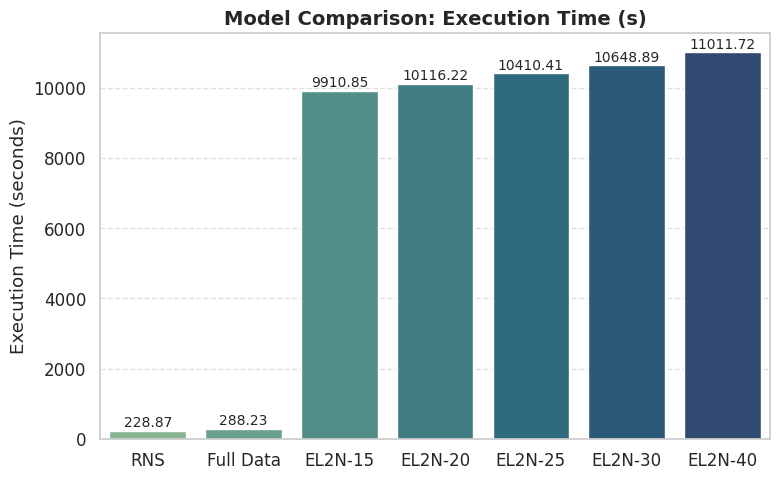

/tmp/ipykernel_1526102/3461729030.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="CO2_kg", data=df, palette="flare")


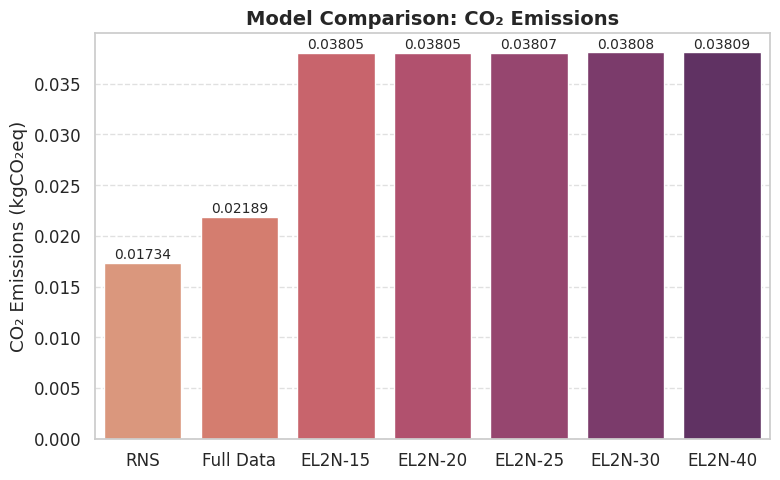

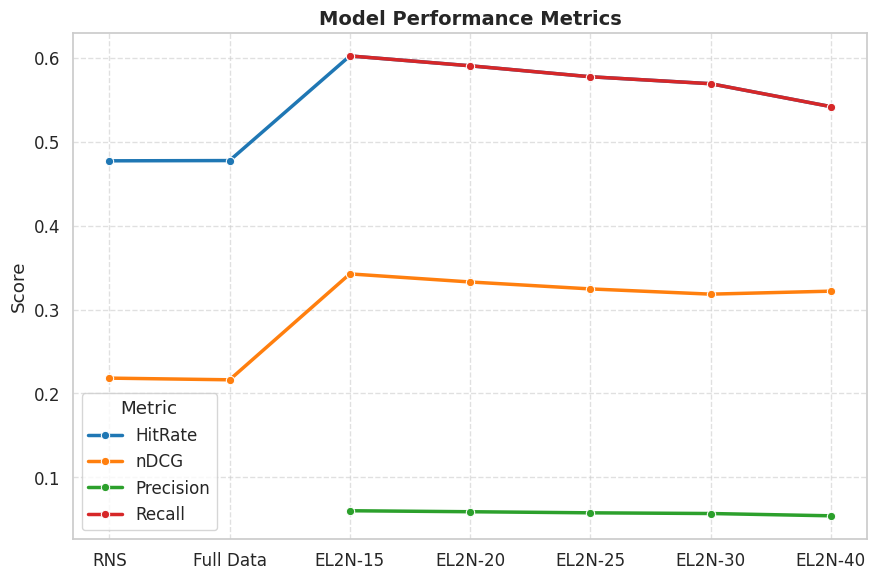

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Data ---
data = {
    "Model": ["RNS", "Full Data", "EL2N-15", "EL2N-20", "EL2N-25", "EL2N-30", "EL2N-40"],
    "Execution_Time_s": [228.87, 288.23, 9910.85, 10116.22, 10410.41, 10648.89, 11011.72],
    "CO2_kg": [0.017342, 0.0218853, 0.038047, 0.038055, 0.038066, 0.038078, 0.038094],
    "HitRate": [0.4773, 0.4776, 0.602318, 0.590563, 0.577483, 0.569205, 0.541887],
    "nDCG": [0.2183, 0.2163, 0.34253, 0.332897, 0.324624, 0.318384, 0.321951],
    "Precision": [None, None, 0.060232, 0.059056, 0.057748, 0.056921, 0.054189],
    "Recall": [None, None, 0.602318, 0.590563, 0.577483, 0.569205, 0.541887]
}

df = pd.DataFrame(data)

# --- Set professional style ---
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

# --- Plot 1: Execution Time ---
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Execution_Time_s", data=df, palette="crest")
plt.title("Model Comparison: Execution Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Execution Time (seconds)")
plt.xlabel("")
plt.grid(True, axis='y', linestyle="--", alpha=0.6)
for i, val in enumerate(df["Execution_Time_s"]):
    plt.text(i, val + max(df["Execution_Time_s"]) * 0.01, f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# --- Plot 2: CO2 Emissions ---
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="CO2_kg", data=df, palette="flare")
plt.title("Model Comparison: CO₂ Emissions", fontsize=14, fontweight='bold')
plt.ylabel("CO₂ Emissions (kgCO₂eq)")
plt.xlabel("")
plt.grid(True, axis='y', linestyle="--", alpha=0.6)
for i, val in enumerate(df["CO2_kg"]):
    plt.text(i, val + max(df["CO2_kg"]) * 0.01, f"{val:.5f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# --- Plot 3: Model Performance Metrics ---
plt.figure(figsize=(9,6))
metrics_df = df.melt(id_vars="Model", value_vars=["HitRate", "nDCG", "Precision", "Recall"],
                     var_name="Metric", value_name="Score")

sns.lineplot(data=metrics_df, x="Model", y="Score", hue="Metric", marker="o", linewidth=2.5, palette="tab10")
plt.title("Model Performance Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Metric", loc="best", frameon=True)
plt.tight_layout()
plt.show()
